In [1]:
!pip install rdkit

In [ ]:
#TUNING THE PARAMETERS
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

from rdkit import Chem
from rdkit.Chem import AllChem

# ===============================
# LOAD DATA
# ===============================
data = pd.read_csv("qm133885_properties.csv")

smiles = data["SMILES"].values
y = data["H"].values

# ===============================
# EXTRAPOLATION SPLIT
# ===============================
train_mask = (y >= -460) & (y <= -360)
test_mask = ~train_mask

smiles_train_full = smiles[train_mask]
y_train_full = y[train_mask]

smiles_test = smiles[test_mask]
y_test = y[test_mask]

print("Training molecules:", len(smiles_train_full))
print("Test molecules:", len(smiles_test))

# ===============================
# VALIDATION SPLIT FROM TRAINING
# ===============================
smiles_train, smiles_val, y_train, y_val = train_test_split(
    smiles_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42
)

print("Train molecules:", len(smiles_train))
print("Validation molecules:", len(smiles_val))
print("Test molecules:", len(smiles_test))

# ===============================
# MORGAN FP FUNCTION
# ===============================
def smiles_to_fp(smiles_string, radius, nBits):

    mol = Chem.MolFromSmiles(smiles_string)

    if mol is None:
        return np.zeros((nBits,), dtype=np.uint8)

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=radius,
        nBits=nBits
    )

    return np.array(fp, dtype=np.uint8)
    
print("STARTED")

# ===============================
# ONE HIDDEN LAYER ANN
# ===============================
# ===============================
# ANN MODEL
# ===============================
def create_model(input_dim,
                 hidden_layers,
                 lr=0.001,
                 activation="relu"):

    model = tf.keras.Sequential()

    model.add(tf.keras.layers.Input(shape=(input_dim,)))

    # Add hidden layers
    for neurons in hidden_layers:
        model.add(tf.keras.layers.Dense(neurons,
                                        activation=activation))

    # Output layer
    model.add(tf.keras.layers.Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )

    return model
# ===============================
# TUNING PARAMETERS
# ===============================
radius_list = [2, 3]
nBits_list = [1024, 2048, 4096]

architecture_list = [
    (32,),
    (64,),
    (128,),                 # 1 hidden layer
    (256,),
    (512,),
    (1024,),
    (2048,),

    # 2 hidden layers
    (32, 64),
    (64, 128),
    (128, 256),
    (256, 512),
    (512, 1024),
    (1024, 2048),

    # 3 hidden layers
    (32, 64, 128),
    (64, 128, 256),
    (128, 256, 512),
    (256, 512, 1024),
    (512, 1024, 2048)
]
lr_list = [0.001]
results = []

best_val_r2 = -999
best_result = None

total_runs = (
    len(radius_list)
    * len(nBits_list)
    * len(architecture_list)
    * len(lr_list)
)
run = 1

# ===============================
# MORGAN FP LOOP
# ===============================
for radius in radius_list:

    for nBits in nBits_list:

        print("\n====================================")
        print(f"Generating Morgan FP: radius={radius}, nBits={nBits}")
        print("====================================")

        # ---------------------------
        # Generate fingerprints ONCE
        # ---------------------------
        X_train = np.array([
            smiles_to_fp(sm, radius, nBits)
            for sm in smiles_train
        ])

        X_val = np.array([
            smiles_to_fp(sm, radius, nBits)
            for sm in smiles_val
        ])

        X_test = np.array([
            smiles_to_fp(sm, radius, nBits)
            for sm in smiles_test
        ])

        # ---------------------------
        # Scale X
        # ---------------------------
        x_scaler = StandardScaler()

        X_train_scaled = x_scaler.fit_transform(X_train)
        X_val_scaled = x_scaler.transform(X_val)
        X_test_scaled = x_scaler.transform(X_test)

        # ---------------------------
        # Scale y
        # ---------------------------
        y_scaler = StandardScaler()

        y_train_scaled = y_scaler.fit_transform(
            y_train.reshape(-1, 1)
        ).flatten()

        y_val_scaled = y_scaler.transform(
            y_val.reshape(-1, 1)
        ).flatten()

        # ===========================
        # ANN TUNING LOOP
        # ===========================
        for architecture in architecture_list:

            for lr in lr_list:

                print(
                    f"\n[{run}/{total_runs}] "
                    f"radius={radius}, "
                    f"nBits={nBits}, "
                    f"architecture={architecture}, "
                    f"lr={lr}"
                )
                # -----------------------
                # Build model
                # -----------------------
                model = create_model(
                    input_dim=nBits,
                    hidden_layers=architecture,
                    lr=lr
                )

                # -----------------------
                # Train
                # -----------------------
                history = model.fit(
                    X_train_scaled,
                    y_train_scaled,
                    validation_data=(
                        X_val_scaled,
                        y_val_scaled
                    ),
                    epochs=100,
                    batch_size=100,
                    verbose=0
                )

                # -----------------------
                # Predictions
                # -----------------------
                y_train_pred = y_scaler.inverse_transform(
                    model.predict(
                        X_train_scaled,
                        verbose=0
                    )
                ).flatten()

                y_val_pred = y_scaler.inverse_transform(
                    model.predict(
                        X_val_scaled,
                        verbose=0
                    )
                ).flatten()

                y_test_pred = y_scaler.inverse_transform(
                    model.predict(
                        X_test_scaled,
                        verbose=0
                    )
                ).flatten()

                # -----------------------
                # R² Scores
                # -----------------------
                r2_train = r2_score(
                    y_train,
                    y_train_pred
                )

                r2_val = r2_score(
                    y_val,
                    y_val_pred
                )

                r2_test = r2_score(
                    y_test,
                    y_test_pred
                )

                print(
                    f"Train R²={r2_train:.4f} | "
                    f"Val R²={r2_val:.4f} | "
                    f"Test R²={r2_test:.4f}"
                )

                result = {
                    "radius": radius,
                    "nBits": nBits,
                    "architecture": str(architecture),
                    "hidden_layers": len(architecture),
                    "lr": lr,
                    "r2_train": r2_train,
                    "r2_val": r2_val,
                    "r2_test": r2_test
                }

                results.append(result)

                # -----------------------
                # Save Best Model
                # -----------------------
                if r2_val > best_val_r2:

                    best_val_r2 = r2_val
                    best_result = result

                run += 1

# ===============================
# RESULTS DATAFRAME
# ===============================
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="r2_val",
    ascending=False
)

print("\n====================================")
print("TOP 10 RESULTS")
print("====================================")

print(results_df.head(10))

# Save results
results_df.to_csv(
    "Morgan_ANN_Tuning_Results.csv",
    index=False
)

# ===============================
# BEST RESULT
# ===============================
print("\n====================================")
print("BEST RESULT")
print("====================================")

print("Radius :", best_result["radius"])
print("nBits  :", best_result["nBits"])
print("Neurons:", best_result["neurons"])
print("LR     :", best_result["lr"])

print("\nTrain R² :", best_result["r2_train"])
print("Val R²   :", best_result["r2_val"])
print("Test R²  :", best_result["r2_test"])

Training molecules: 109016
Test molecules: 24869
Train molecules: 87212
Validation molecules: 21804
Test molecules: 24869
STARTED

Generating Morgan FP: radius=2, nBits=1024


Input vector shape: (133885, 1024)
Fixed Test Samples: 24869

Training Fraction = 15%
Training Samples = 16352
Epoch 1/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.2312 - mae: 1.1572 - val_loss: 0.8139 - val_mae: 0.7127
Epoch 2/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6469 - mae: 0.6342 - val_loss: 0.6640 - val_mae: 0.6360
Epoch 3/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.4134 - mae: 0.5043 - val_loss: 0.6223 - val_mae: 0.6058
Epoch 4/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3076 - mae: 0.4324 - val_loss: 0.5787 - val_mae: 0.5830
Epoch 5/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2339 - mae: 0.3758 - val_loss: 0.5715 - val_mae: 0.5791
Epoch 6/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1992 - mae: 0.3485 - val_loss: 0.5664 - val_mae: 0.5745
Epoch 7/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1758 - mae: 0.3263 - val_loss: 0.5637 - val_mae: 0.5765
Epoch 8/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - l

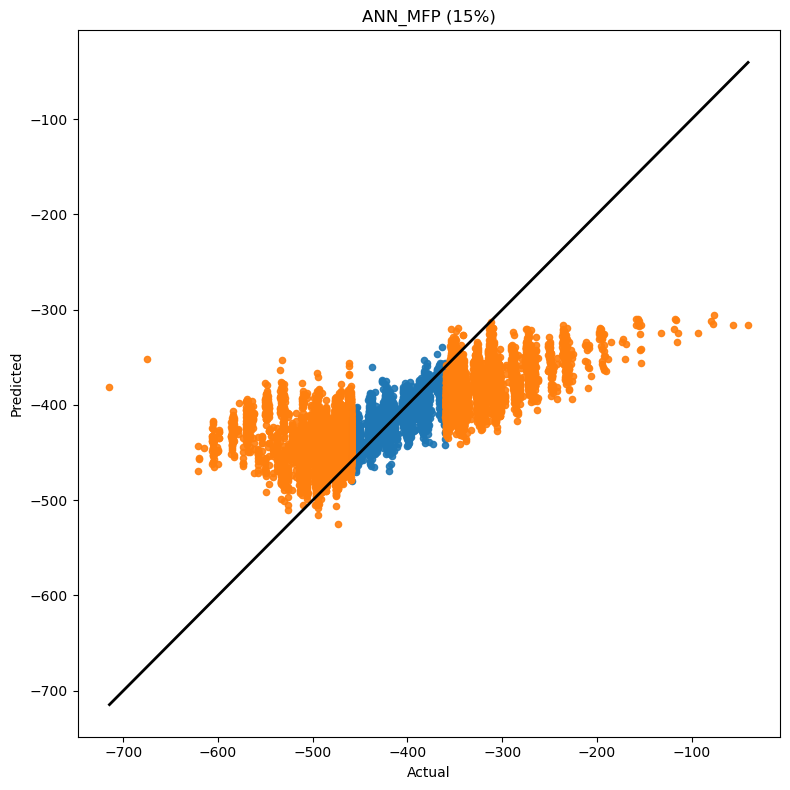

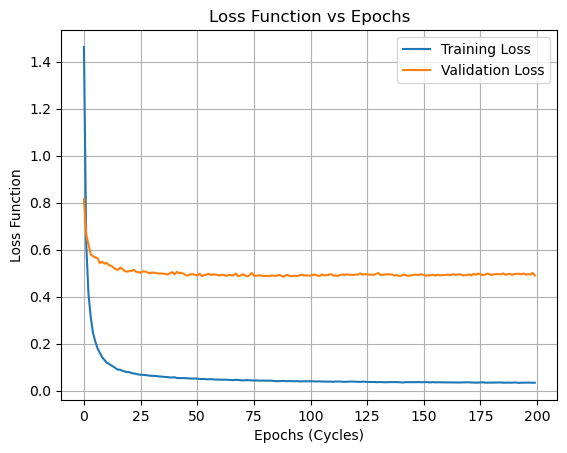

Scaled Test Loss: [3.5878424644470215, 1.5400187969207764]

Training Fraction = 30%
Training Samples = 32704
Epoch 1/200
262/262 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.2169 - mae: 0.8574 - val_loss: 0.5322 - val_mae: 0.5677
Epoch 2/200
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.4226 - mae: 0.5009 - val_loss: 0.4690 - val_mae: 0.5250
Epoch 3/200
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3291 - mae: 0.4389 - val_loss: 0.4536 - val_mae: 0.5127
Epoch 4/200
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2721 - mae: 0.3960 - val_loss: 0.4467 - val_mae: 0.5063
Epoch 5/200
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2271 - mae: 0.3634 - val_loss: 0.4542 - val_mae: 0.5155
Epoch 6/200
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1952 - mae: 0.3379 - val_loss: 0.4552 - val_mae: 0.5147
Epoch 7/200
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1741 - mae: 0.3212 - val_loss: 0.4539 - val_mae: 0.5125
Epoch 8/200
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - los

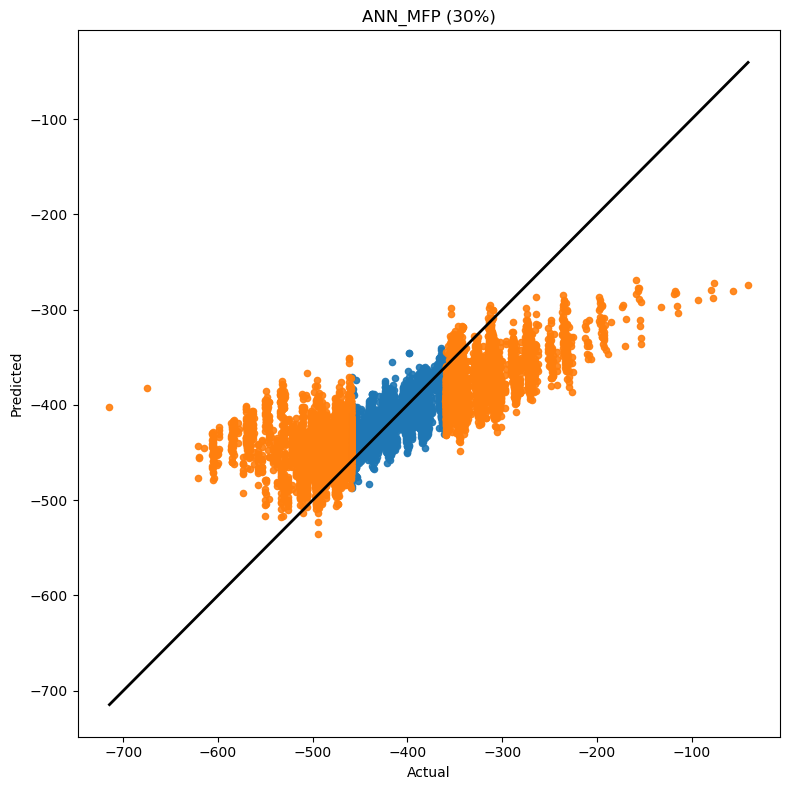

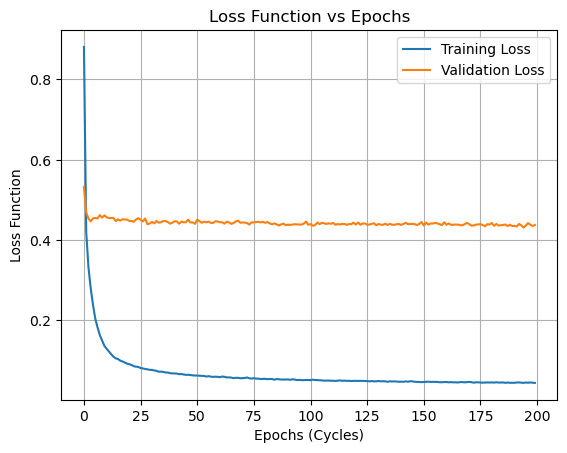

Scaled Test Loss: [3.0445144176483154, 1.3850713968276978]

Training Fraction = 45%
Training Samples = 49057
Epoch 1/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 1.2830 - mae: 0.8701 - val_loss: 0.4886 - val_mae: 0.5354
Epoch 2/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.4232 - mae: 0.4992 - val_loss: 0.4341 - val_mae: 0.4983
Epoch 3/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3385 - mae: 0.4408 - val_loss: 0.4226 - val_mae: 0.4900
Epoch 4/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2843 - mae: 0.4030 - val_loss: 0.4185 - val_mae: 0.4877
Epoch 5/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2451 - mae: 0.3767 - val_loss: 0.4164 - val_mae: 0.4869
Epoch 6/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2179 - mae: 0.3549 - val_loss: 0.4155 - val_mae: 0.4908
Epoch 7/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1925 - mae: 0.3343 - val_loss: 0.4223 - val_mae: 0.4954
Epoch 8/200
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - los

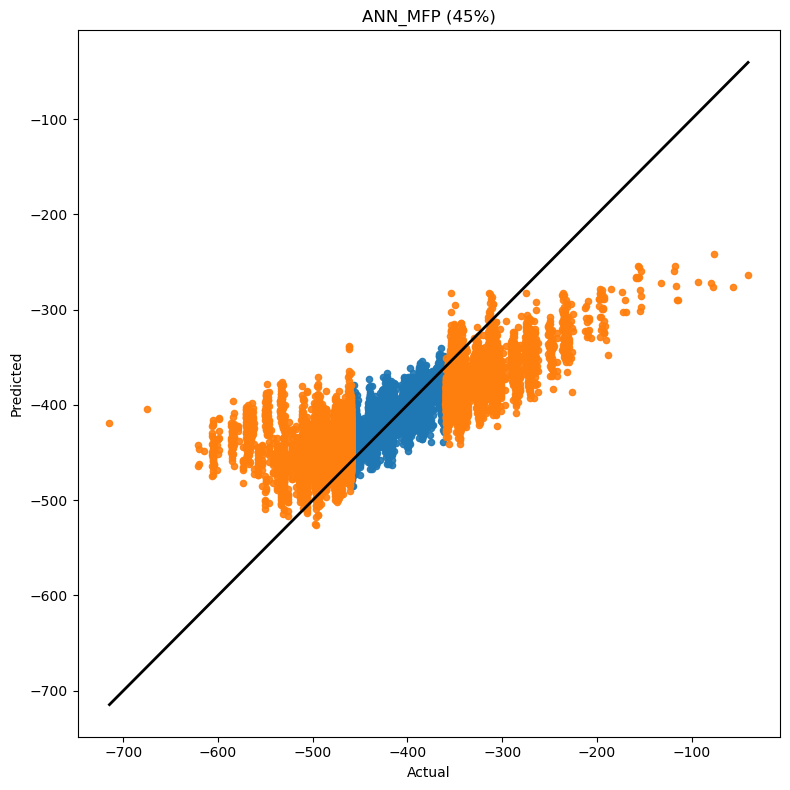

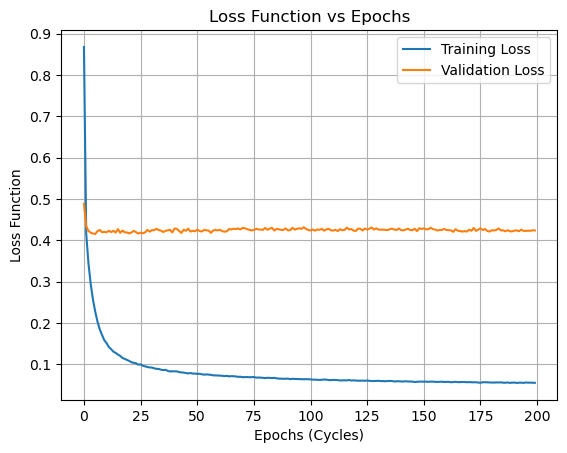

Scaled Test Loss: [2.8622686862945557, 1.3408290147781372]

Training Fraction = 60%
Training Samples = 65409
Epoch 1/200
524/524 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1.0597 - mae: 0.7881 - val_loss: 0.4552 - val_mae: 0.5122
Epoch 2/200
524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3949 - mae: 0.4777 - val_loss: 0.4203 - val_mae: 0.4813
Epoch 3/200
524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3295 - mae: 0.4312 - val_loss: 0.4069 - val_mae: 0.4730
Epoch 4/200
524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2860 - mae: 0.4021 - val_loss: 0.4004 - val_mae: 0.4733
Epoch 5/200
524/524 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.2485 - mae: 0.3776 - val_loss: 0.4003 - val_mae: 0.4729
Epoch 6/200
524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2230 - mae: 0.3596 - val_loss: 0.3984 - val_mae: 0.4739
Epoch 7/200
524/524 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2015 - mae: 0.3423 - val_loss: 0.4049 - val_mae: 0.4821
Epoch 8/200
524/524 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - los

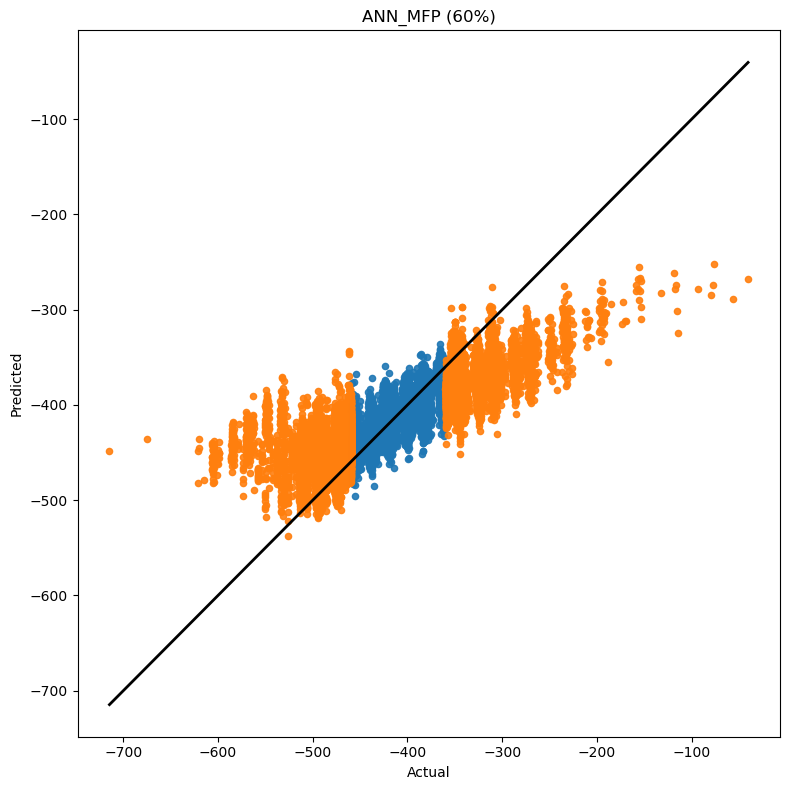

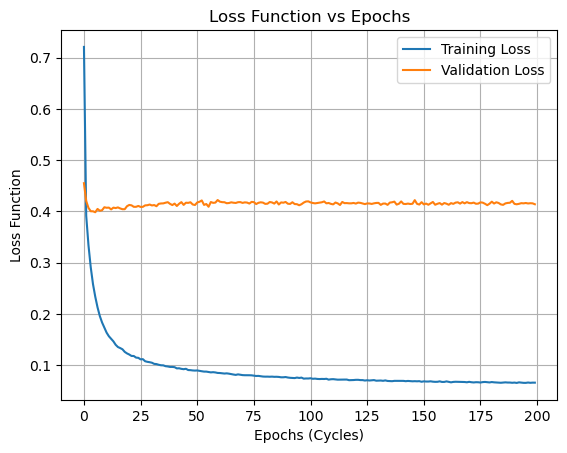

Scaled Test Loss: [2.674563407897949, 1.2700685262680054]

Training Fraction = 75%
Training Samples = 81762
Epoch 1/200
655/655 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 2.2259 - mae: 1.0682 - val_loss: 0.5063 - val_mae: 0.5493
Epoch 2/200
655/655 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.4420 - mae: 0.5133 - val_loss: 0.4263 - val_mae: 0.4934
Epoch 3/200
655/655 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.3370 - mae: 0.4408 - val_loss: 0.4081 - val_mae: 0.4779
Epoch 4/200
655/655 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.2954 - mae: 0.4108 - val_loss: 0.3960 - val_mae: 0.4713
Epoch 5/200
655/655 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.2645 - mae: 0.3890 - val_loss: 0.3910 - val_mae: 0.4681
Epoch 6/200
655/655 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.2434 - mae: 0.3741 - val_loss: 0.3891 - val_mae: 0.4685
Epoch 7/200
655/655 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.2272 - mae: 0.3639 - val_loss: 0.3823 - val_mae: 0.4646
Epoch 8/200
655/655 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss

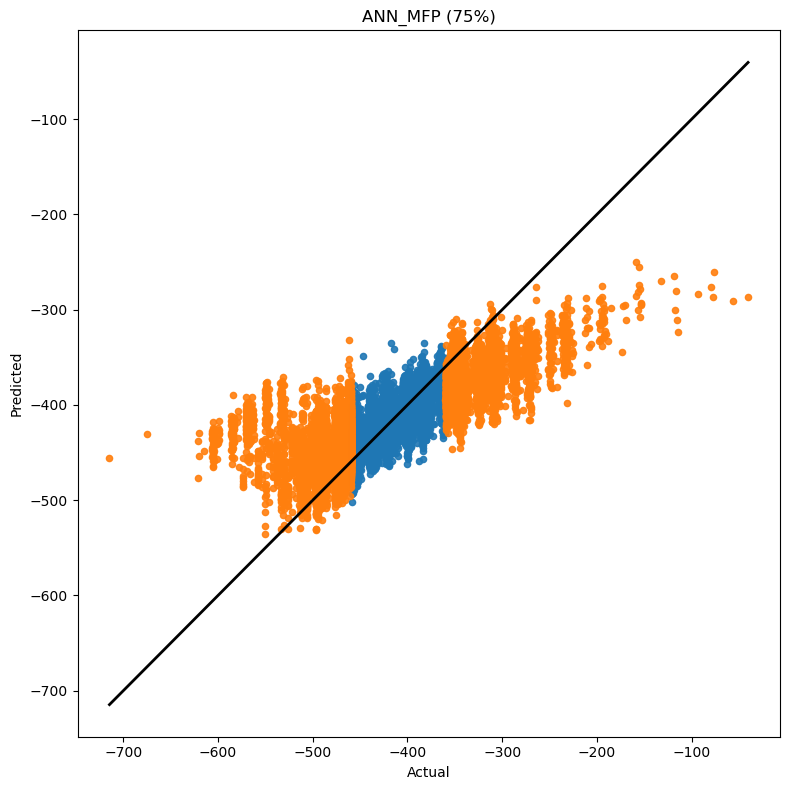

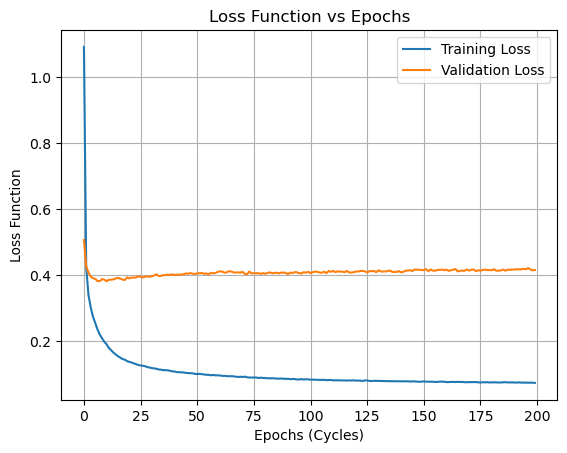

Scaled Test Loss: [2.6882479190826416, 1.2385764122009277]

Training Fraction = 90%
Training Samples = 98114
Epoch 1/200
785/785 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 1.2639 - mae: 0.8429 - val_loss: 0.4487 - val_mae: 0.5044
Epoch 2/200
785/785 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.3908 - mae: 0.4712 - val_loss: 0.4084 - val_mae: 0.4767
Epoch 3/200
785/785 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.3357 - mae: 0.4324 - val_loss: 0.3934 - val_mae: 0.4661
Epoch 4/200
785/785 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.2917 - mae: 0.4040 - val_loss: 0.3815 - val_mae: 0.4648
Epoch 5/200
785/785 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.2673 - mae: 0.3884 - val_loss: 0.3766 - val_mae: 0.4632
Epoch 6/200
785/785 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.2429 - mae: 0.3723 - val_loss: 0.3719 - val_mae: 0.4561
Epoch 7/200
785/785 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.2234 - mae: 0.3580 - val_loss: 0.3701 - val_mae: 0.4591
Epoch 8/200
785/785 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - los

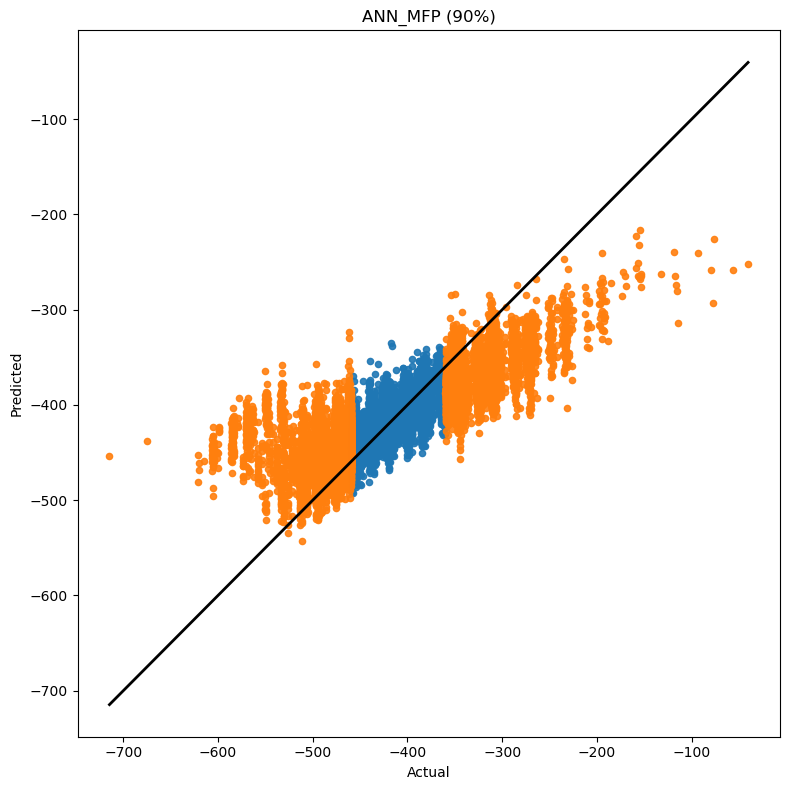

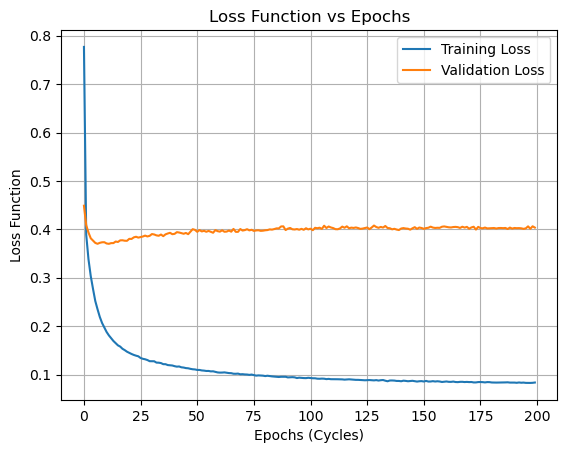

Scaled Test Loss: [2.501600503921509, 1.1953883171081543]


In [2]:
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

from rdkit import Chem
from rdkit.Chem import AllChem

# ===============================
# LOAD DATA
# ===============================
data = pd.read_csv("qm133885_properties.csv")

smiles = data["SMILES"].values
H=data['H']

def smiles_to_fingerprint(smiles_string):
    mol = Chem.MolFromSmiles(smiles_string)
    if mol is None:
        return np.zeros((1024,), dtype=int)

    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=3, nBits=1024)
    return np.array(fp, dtype=int)

# Apply the fingerprint conversion
X = np.array([smiles_to_fingerprint(sm) for sm in smiles])
y = H.values
print("Input vector shape:", X.shape)

# ===============================
# EXTRAPOLATION SPLIT
# ===============================

train_mask = (y >= -460) & (y <= -360)
test_mask = ~train_mask

X_train_full = X[train_mask]
y_train_full = y[train_mask]

X_test_all = X[test_mask]
y_test_all = y[test_mask]

# ===============================
# ===============================
# FIX TEST SET TO 24,869 SAMPLES
# ===============================

np.random.seed(42)

test_indices = np.random.choice(
    len(X_test_all),
    size=24869,
    replace=False
)
X_test = X_test_all[test_indices]
y_test = y_test_all[test_indices]

print("Fixed Test Samples:", len(X_test))
# ===============================

fractions = [0.15, 0.30, 0.45, 0.60, 0.75, 0.90]

for frac in fractions:

    train_size = int(frac * len(X_train_full))
    np.random.default_rng(42)
    idx = np.random.choice(
        len(X_train_full),
        train_size,
        replace=False
    )

    X_train_sub = X_train_full[idx]
    y_train_sub = y_train_full[idx]

    print(f"\nTraining Fraction = {frac*100:.0f}%")
    print("Training Samples =", len(X_train_sub))

    # -----------------------------
    # Scale X and y
    # -----------------------------
    x_scaler = StandardScaler() 
    y_scaler = StandardScaler() 

    X_train_scaled = x_scaler.fit_transform(X_train_sub) 
    X_test_scaled = x_scaler.transform(X_test)

    y_train_scaled = y_scaler.fit_transform(y_train_sub.reshape(-1,1)).flatten()
    y_test_scaled  = y_scaler.transform(y_test.reshape(-1,1)).flatten()

    # Construction of model
    # Build the DNN model
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(1024,)),  # Input layer matching fingerprint size
        tf.keras.layers.Dense(128, activation='relu',  kernel_regularizer=l2(1e-5) ,kernel_initializer='he_normal'),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(1)  # Output layer for regression
    ])
    #%%
    # Compile the model
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

    # Train the model
    history = model.fit(
        X_train_scaled,
        y_train_scaled,
        validation_split=0.2,
        epochs=200,
        batch_size=100,
        verbose=1
    )
    print(history.history.keys())
    
    # Make predictions
    # Predict (scaled output)
    y_pred_train_scaled = model.predict(X_train_scaled)
    y_pred_test_scaled  = model.predict(X_test_scaled)

    # Inverse transform predictions
    y_pred_train = y_scaler.inverse_transform(y_pred_train_scaled).flatten()
    y_pred_test  = y_scaler.inverse_transform(y_pred_test_scaled).flatten()

    # Metrics on ORIGINAL y
    mse_train = mean_squared_error(y_train_sub, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train_sub, y_pred_train)

    mse_test = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_pred_test)

    print("\nResults")
    print("-"*40)
    print(f"Train MSE : {mse_train:.4f}")
    print(f"Train R²  : {r2_train:.4f}")
    print(f"Train RMSE : {rmse_train:.4f}")
    print(f"Test MSE  : {mse_test:.4f}")
    print(f"Test R²   : {r2_test:.4f}")
    print(f"Test RMSE  : {rmse_test:.4f}")

    #%%
    # Total data points
    total_data_points = len(smiles)
    data_points_used_for_training = len(X_train_sub)
    data_points_used_for_testing = len(X_test)

    #%% Print the total and split data points
    print(f'Total Data Points: {total_data_points}')
    print(f'Number of Data Points Used for Training: {data_points_used_for_training}')
    print(f'Number of Data Points Used for Testing: {data_points_used_for_testing}')

    # ===============================
    # TRAIN PARITY PLOT
    # ===============================

    plt.figure(figsize=(8,8))

    plt.scatter(
        y_train_sub,
        y_pred_train,
        s=20,
        alpha=0.9
    )

    # ===============================
    # TEST PARITY PLOT
    # ===============================
    plt.scatter(
        y_test,
        y_pred_test,
        s=20,
        alpha=0.9
    )

    min_val = min(y_train_sub.min(), y_pred_train.min(),y_test.min(), y_pred_test.min())
    max_val = max(y_train_sub.max(), y_pred_train.max(),y_test.max(), y_pred_test.max())

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        'k-',
        linewidth=2
    )

    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'ANN_MFP ({int(frac*100)}%)')
    plt.savefig(f"MFP_ANN_Parity_{int(frac*100)}.png",
            dpi=600,
            bbox_inches='tight')
    plt.tight_layout()
    plt.show()

    #%%
    # Plot training & validation loss values
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')

    plt.xlabel('Epochs (Cycles)')
    plt.ylabel('Loss Function')
    plt.title('Loss Function vs Epochs')
    plt.legend()
    plt.savefig(f"lossvsepoch_ANN_{int(frac*100)}.png",dpi=300)
    plt.grid(True)
    plt.show()

    # Final train & validation loss
    final_train_loss = history.history['loss'][-1]
    final_val_loss   = history.history['val_loss'][-1]

    # Evaluate test set (returns only loss)
    test_loss = model.evaluate(X_test_scaled, y_test_scaled, verbose=0)
    print("Scaled Test Loss:", test_loss)

#Thankyou!!!!

